In [30]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from tqdm import tqdm
import joblib
from pathlib import Path

In [31]:
year = 2021
RAW_XY_FOLDERPATH = Path(f'../data/silver/Xy-{year}')

# Load data

In [32]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet")
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet")

raw_Xy.head(1)

,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,red_11x11_median,...,ndwi_11x11_var,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median
1,0.121569,0.121569,0.109804,0.129412,0.007843,0.117647,0.109804,0.129412,0.007843,0.117647,...,-0.230769,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099


# Build Xy

In [33]:
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', 'region']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    features += [e for e in X.columns if any(k in e for k in ['3x3', '5x5', '11x11'])]
    return X[features + ['y']]

Xy = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(raw_Xy)
Xy.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median,y
1,0.058824,0.086275,0.121569,0.160784,0.180392,0.196078,0.196078,0.203922,0.239216,0.180392,...,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099,False


# Prep hyperparam optimization

In [34]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, precision_score, recall_score

def optuna_objective_factory(X, y, groups, n_splits: int = 100):
    # Safely determine max possible splits based on unique groups
    unique_groups = len(np.unique(groups))
    actual_splits = min(n_splits, unique_groups)
    
    if actual_splits < n_splits:
        print(f"Warning: Requested {n_splits} splits, but only found {unique_groups} unique groups. Adjusting n_splits to {actual_splits}.")

    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        gkf = GroupKFold(n_splits=actual_splits)
        
        # Initialize lists to store metrics and raw arrays
        true_f1s, true_precisions, true_recalls = [], [], []
        false_f1s, false_precisions, false_recalls = [], [], []
        all_yhat_vals, all_y_vals = [], []
        
        for train_idx, val_idx in gkf.split(X, y, groups):
            # Safe slicing regardless of whether X/y are pandas DataFrames/Series or numpy arrays
            X_train = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx] 
            
            # Fit/predict
            model = lgb.LGBMClassifier(**param)
            model.fit(X_train, y_train)
            yhat_val = model.predict(X_val)
            
            # Calculate and append metrics
            true_f1s.append(f1_score(y_val, yhat_val, zero_division=0))
            true_precisions.append(precision_score(y_val, yhat_val, zero_division=0))
            true_recalls.append(recall_score(y_val, yhat_val, zero_division=0))

            false_f1s.append(f1_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_precisions.append(precision_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_recalls.append(recall_score(y_val, yhat_val, zero_division=0, pos_label=0))
            
            all_yhat_vals.append(yhat_val.tolist())
            all_y_vals.append(y_val.tolist())

        # Store tracked data as user attributes in the trial
        trial.set_user_attr('true_f1s', true_f1s)
        trial.set_user_attr('true_precisions', true_precisions)
        trial.set_user_attr('true_recalls', true_recalls)
        trial.set_user_attr('false_f1s', false_f1s)
        trial.set_user_attr('false_precisions', false_precisions)
        trial.set_user_attr('false_recalls', false_recalls)
        trial.set_user_attr('yhat_vals', all_yhat_vals)
        trial.set_user_attr('y_vals', all_y_vals)
        
        return np.median(true_f1s)

    return objective

# Train:test split

In [35]:
def compute_a(y):
    return y.sum() / len(y)

def compute_ahat(yhat, y_vals, yhat_vals):
    area_proportion_1 = yhat.sum() / len(yhat)
    area_proportion_0 = 1 - area_proportion_1
    
    # Figure out precision/false-omission-rate as the weighted-mean
    cms = [confusion_matrix(y_val, yhat_val, labels=[True, False]) for y_val, yhat_val in zip(y_vals, yhat_vals)] # (tp, fn), (fp, tn)
    tps = [e[0][0] for e in cms]
    fns = [e[0][1] for e in cms]
    tns = [e[1][1] for e in cms]
    fps = [e[1][0] for e in cms]

    # Figure out weighted-averaged TN, ...
    n_vals = np.array([len(e) for e in y_vals])
    tp = np.mean(tps)
    fn = np.mean(fns)
    fp = np.mean(fps)
    tn = np.mean(tns)

    # Compute validation set's metrics
    false_omission_rate = fn / (fn + tn)
    precision = tp / (tp + fp)

    # Compute adjusted unbiased area proportion
    ahat = (area_proportion_1 * precision) + (area_proportion_0 * false_omission_rate)

    # Compute Confidence Interval (Olofsson Variance)
    n_cocoa = tp + fp
    n_non_cocoa = fn + tn

    # Variance contribution from both strata
    var_cocoa = (area_proportion_1 ** 2) * (precision * (1 - precision)) / (n_cocoa - 1)
    var_non_cocoa = (area_proportion_0 ** 2) * (false_omission_rate * (1 - false_omission_rate)) / (n_non_cocoa - 1)
    
    # Standard Error
    se = np.sqrt(var_cocoa + var_non_cocoa)
    
    # Margin of Error for 95% Confidence Interval (Z-score = 1.96)
    margin_of_error = 1.96 * se
    
    ci_lower = max(0.0, ahat - margin_of_error) # Clamp at 0%
    ci_upper = min(1.0, ahat + margin_of_error) # Clamp at 100%

    return ahat, (ci_lower, ci_upper)

In [36]:
def train_test_split(Xy, metadata_df, region: str, test_size=0.2):
    """Split a train/test set, where all test samples are located within a region."""
    region_mask = Xy.region.apply(lambda x: x.lower()) == region

    if not region_mask.sum():
        raise ValueError(f'Region {region} not found.')

    # Discard not-in-region data
    Xy = Xy[region_mask]
    metadata_df = metadata_df[region_mask]
    print(f"Discarding out-of-region points: Kept {region_mask.sum()}/{len(region_mask)} ({region_mask.sum()/len(region_mask) * 100:.2f}%)")
    Xy = Xy.drop(columns=['region'])
    
    # Figure out which folds are for train/val and which for test
    region_fold_idxs = metadata_df.fold_idx[region_mask].unique()
    n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
    test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
    test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
    print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")
    
    return Xy[~test_mask], metadata_df[~test_mask], Xy[test_mask], metadata_df[test_mask]

Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, 'upper east', 0.2)
Xy_train.head(1)

Discarding out-of-region points: Kept 34820/915540 (3.80%)
200/1000 regions for testing (6984 points)


,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median,y
1,0.058824,0.086275,0.121569,0.160784,0.180392,0.196078,0.196078,0.203922,0.239216,0.180392,...,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099,False


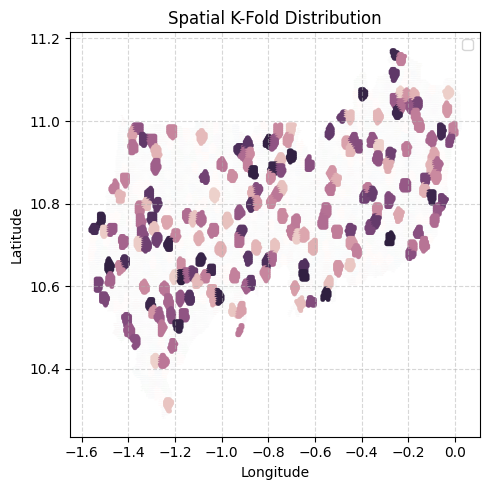

In [37]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=train_metadata_df, x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.02, edgecolor=None)
sns.scatterplot(data=test_metadata_df, x='lon', y='lat', hue='fold_idx', color='r', s=10, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train

In [41]:
def train_test_lgbm(X_train, y_train, X_test, y_test, groups, n_splits=2, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, n_splits), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)

    # Validation-inferred correction
    yhat_vals = [np.array(e) for e in study.best_trial.user_attrs['yhat_vals']]
    y_vals = [np.array(e) for e in study.best_trial.user_attrs['y_vals']]
    ahat, (ci_lower, ci_upper) = compute_ahat(yhat_test, y_vals, yhat_vals)
    a = compute_a(y_test)
    print(f"Test region's estimated CAP: {ahat*100:.2f}% ({100 * ahat / a - 100:.2f}% off ETHZ's estimate)")
    print(f"95% Confidence Interval: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- F1: {f1_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_train, yhat_train, zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- F1: {f1_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_test, yhat_test, zero_division=0):.4f}")

    return clf, study.best_trial.user_attrs

In [44]:
def train_region(Xy, metadata_df, region, test_size=0.2, n_trials=100):
    
    # Get train:test
    Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, region.lower(), test_size)    
    X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
    X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

    # Train
    clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, train_metadata_df.fold_idx, n_trials=n_trials);
    
    # Dump
    payload = {
        'X_train': X_train,
        'y_train': y_train,
        'metadata_df_train':  train_metadata_df,
        'X_test': X_test,
        'y_test': y_test,
        'metadata_df_test':  test_metadata_df,
        'clf': clf,
        "user_attrs": user_attrs,
    }
    
    joblib.dump(payload, f'trained-{region.lower()}-2021.joblib')

In [45]:
train_region(Xy, metadata_df, 'ashanti', 0.2, n_trials=1)

Discarding out-of-region points: Kept 95807/915540 (10.46%)
200/1000 regions for testing (19321 points)


[I 2026-06-23 16:53:08,567] A new study created in memory with name: no-name-eba0c8b7-f8c1-4f7c-869a-e47f7cacdb73


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 16:53:11,616] Trial 0 finished with value: 0.7786982356263134 and parameters: {'n_estimators': 66, 'learning_rate': 0.1726080942165134, 'max_depth': 13, 'num_leaves': 78, 'subsample': 0.7581595190307663, 'colsample_bytree': 0.9922859707323896, 'min_child_samples': 99}. Best is trial 0 with value: 0.7786982356263134.
Test region's estimated CAP: 26.07% (-4.54% off ETHZ's estimate)
95% Confidence Interval: [25.76%, 26.39%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.8926
- Precision: 0.8837
- Recall: 0.9016

TEST
- F1: 0.7949
- Precision: 0.8127
- Recall: 0.7779


In [46]:
train_region(Xy, metadata_df, 'western north', 0.2, n_trials=1)

[I 2026-06-23 16:54:00,875] A new study created in memory with name: no-name-9201618f-28dd-4990-bb68-3356c143d422


Discarding out-of-region points: Kept 32268/915540 (3.52%)
200/1000 regions for testing (6447 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 16:54:03,304] Trial 0 finished with value: 0.8284277401646696 and parameters: {'n_estimators': 80, 'learning_rate': 0.013054821597947089, 'max_depth': 8, 'num_leaves': 202, 'subsample': 0.6378839558867615, 'colsample_bytree': 0.9068761601804156, 'min_child_samples': 27}. Best is trial 0 with value: 0.8284277401646696.
Test region's estimated CAP: 49.26% (2.98% off ETHZ's estimate)
95% Confidence Interval: [48.60%, 49.93%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.8637
- Precision: 0.7864
- Recall: 0.9579

TEST
- F1: 0.8245
- Precision: 0.7458
- Recall: 0.9219


In [47]:
train_region(Xy, metadata_df, 'western', 0.2, n_trials=1)

[I 2026-06-23 16:54:05,471] A new study created in memory with name: no-name-aa80b5e8-a7b7-472f-9a2a-dc5b2c99f524


Discarding out-of-region points: Kept 37872/915540 (4.14%)
200/1000 regions for testing (7542 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 16:54:06,228] Trial 0 finished with value: 0.7447731558941187 and parameters: {'n_estimators': 72, 'learning_rate': 0.02379621680795002, 'max_depth': 3, 'num_leaves': 237, 'subsample': 0.6687488389198553, 'colsample_bytree': 0.767939131024258, 'min_child_samples': 13}. Best is trial 0 with value: 0.7447731558941187.
Test region's estimated CAP: 42.12% (-3.61% off ETHZ's estimate)
95% Confidence Interval: [41.47%, 42.77%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.7499
- Precision: 0.7509
- Recall: 0.7488

TEST
- F1: 0.7609
- Precision: 0.7754
- Recall: 0.7470


In [48]:
train_region(Xy, metadata_df, 'ahafo', 0.2, n_trials=1)

[I 2026-06-23 16:54:06,903] A new study created in memory with name: no-name-a995a346-c22b-4ce6-b7c6-60081cd52986


Discarding out-of-region points: Kept 20052/915540 (2.19%)
200/1000 regions for testing (4039 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 16:54:07,255] Trial 0 finished with value: 0.7992563279937022 and parameters: {'n_estimators': 65, 'learning_rate': 0.09085553967906777, 'max_depth': 3, 'num_leaves': 98, 'subsample': 0.8528514930009867, 'colsample_bytree': 0.6853722892366176, 'min_child_samples': 85}. Best is trial 0 with value: 0.7992563279937022.
Test region's estimated CAP: 42.24% (2.09% off ETHZ's estimate)
95% Confidence Interval: [41.41%, 43.06%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.8136
- Precision: 0.7902
- Recall: 0.8385

TEST
- F1: 0.7936
- Precision: 0.7578
- Recall: 0.8330


In [49]:
train_region(Xy, metadata_df, 'central', 0.2, n_trials=1)

[I 2026-06-23 16:54:07,656] A new study created in memory with name: no-name-7cfa2849-7f86-49fc-bf32-9bcd07e663a1


Discarding out-of-region points: Kept 32385/915540 (3.54%)
200/1000 regions for testing (6340 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-23 16:54:09,545] Trial 0 finished with value: 0.7728749640572687 and parameters: {'n_estimators': 74, 'learning_rate': 0.07788288856283898, 'max_depth': 15, 'num_leaves': 54, 'subsample': 0.5834322353333139, 'colsample_bytree': 0.7345694212336282, 'min_child_samples': 16}. Best is trial 0 with value: 0.7728749640572687.
Test region's estimated CAP: 34.26% (6.52% off ETHZ's estimate)
95% Confidence Interval: [33.64%, 34.88%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.8639
- Precision: 0.8594
- Recall: 0.8684

TEST
- F1: 0.7584
- Precision: 0.7489
- Recall: 0.7680


# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?